# Demo Rápido — NPS Preditivo para E-commerce

**Objetivo:** Em 5 minutos, carregar os dados, treinar o modelo e classificar clientes por risco de detração.

> Este notebook é um resumo executivo do projeto completo. Para detalhes, consulte as pastas individuais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


## 1. Carregamento e Visão Geral dos Dados

Base com **2.500 pedidos** de e-commerce contendo dados de logística, atendimento e satisfação.

In [2]:
df = pd.read_csv("data/desafio_nps_fase_1.csv")
print(f"Shape: {df.shape[0]} registros × {df.shape[1]} colunas\n")
df.head()

Shape: 2500 registros × 19 colunas



,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Diagnóstico do NPS

Classificação: **Detrator** (≤6) · **Neutro** (7-8) · **Promotor** (≥9)

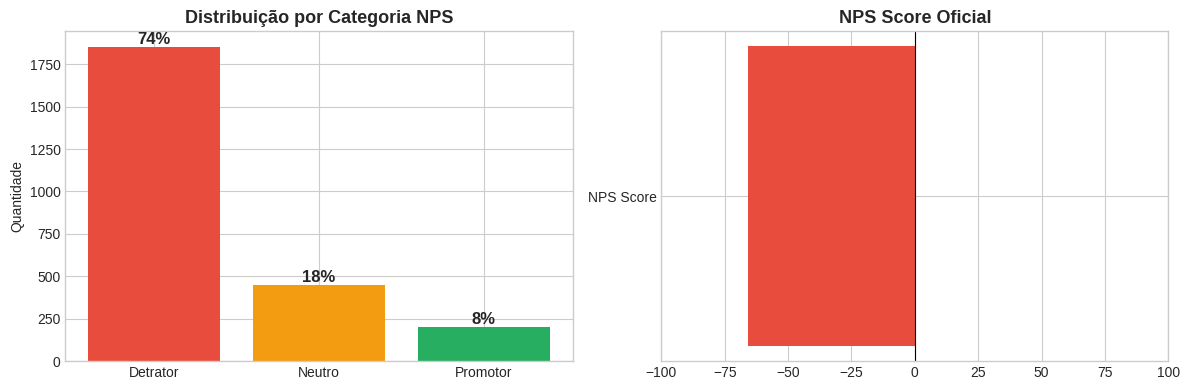


⚠️  NPS Oficial: -66 | 74% detratores — situação crítica


In [3]:
# Classificar NPS
df['nps_category'] = pd.cut(df['nps_score'], bins=[-1, 6, 8, 10], labels=['Detrator', 'Neutro', 'Promotor'])
df['is_detractor'] = (df['nps_score'] <= 6).astype(int)

# NPS Score oficial
pct_promotor = (df['nps_category'] == 'Promotor').mean() * 100
pct_detrator = (df['nps_category'] == 'Detrator').mean() * 100
nps_oficial = pct_promotor - pct_detrator

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição
colors = {'Detrator': '#e74c3c', 'Neutro': '#f39c12', 'Promotor': '#27ae60'}
counts = df['nps_category'].value_counts()
axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
for i, (cat, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 20, f'{val/len(df)*100:.0f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribuição por Categoria NPS', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade')

# NPS Score
color_nps = '#e74c3c' if nps_oficial < 0 else '#27ae60'
axes[1].barh(['NPS Score'], [nps_oficial], color=color_nps, height=0.4)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlim(-100, 100)
axes[1].text(nps_oficial + 3, 0, f'{nps_oficial:.0f}', va='center', fontsize=18, fontweight='bold', color=color_nps)
axes[1].set_title('NPS Score Oficial', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('docs/01_diagnostico_nps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n⚠️  NPS Oficial: {nps_oficial:.0f} | {pct_detrator:.0f}% detratores — situação crítica")

## 3. Principais Drivers de Insatisfação

Os 3 fatores que mais impactam negativamente o NPS são **operacionais**, não demográficos.

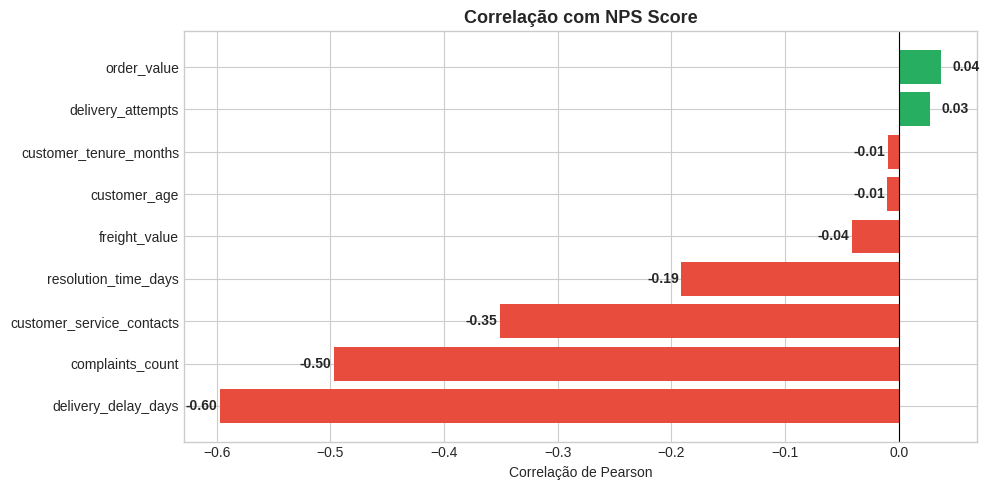


🔑 Insight: atraso de entrega e reclamações são os maiores destruidores de NPS


In [4]:
# Correlação com NPS
features_corr = ['delivery_delay_days', 'complaints_count', 'customer_service_contacts', 
                 'resolution_time_days', 'delivery_attempts', 'freight_value',
                 'customer_age', 'customer_tenure_months', 'order_value']

correlations = df[features_corr + ['nps_score']].corr()['nps_score'].drop('nps_score').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#e74c3c' if v < 0 else '#27ae60' for v in correlations.values]
bars = ax.barh(correlations.index, correlations.values, color=colors_bar)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Correlação com NPS Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlação de Pearson')

for bar, val in zip(bars, correlations.values):
    x_pos = val - 0.03 if val < 0 else val + 0.01
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('docs/02_drivers_nps.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n🔑 Insight: atraso de entrega e reclamações são os maiores destruidores de NPS")

## 4. Feature Engineering

Variáveis derivadas dos **pontos de ruptura** identificados na EDA.

In [5]:
# Features derivadas dos pontos de ruptura da EDA
df['atraso_critico'] = (df['delivery_delay_days'] >= 3).astype(int)
df['reclamacao_alta'] = (df['complaints_count'] >= 5).astype(int)
df['multiplos_contatos'] = (df['customer_service_contacts'] >= 3).astype(int)
df['atraso_x_reclamacao'] = df['delivery_delay_days'] * df['complaints_count']
df['freight_ratio'] = df['freight_value'] / df['order_value']

# Features para o modelo (sem leakage)
feature_cols = [
    'customer_age', 'customer_tenure_months', 'order_value', 'items_quantity',
    'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days',
    'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'atraso_critico', 'reclamacao_alta', 'multiplos_contatos',
    'atraso_x_reclamacao', 'freight_ratio'
]

X = df[feature_cols]
y = df['is_detractor']

print(f"Features: {len(feature_cols)} | Target: is_detractor")
print(f"Distribuição: {y.value_counts().to_dict()}  (1=Detrator, 0=Não-Detrator)")

Features: 18 | Target: is_detractor
Distribuição: {1: 1851, 0: 649}  (1=Detrator, 0=Não-Detrator)


## 5. Modelo — Random Forest

Treinamento com split estratificado 75/25 e avaliação no holdout.

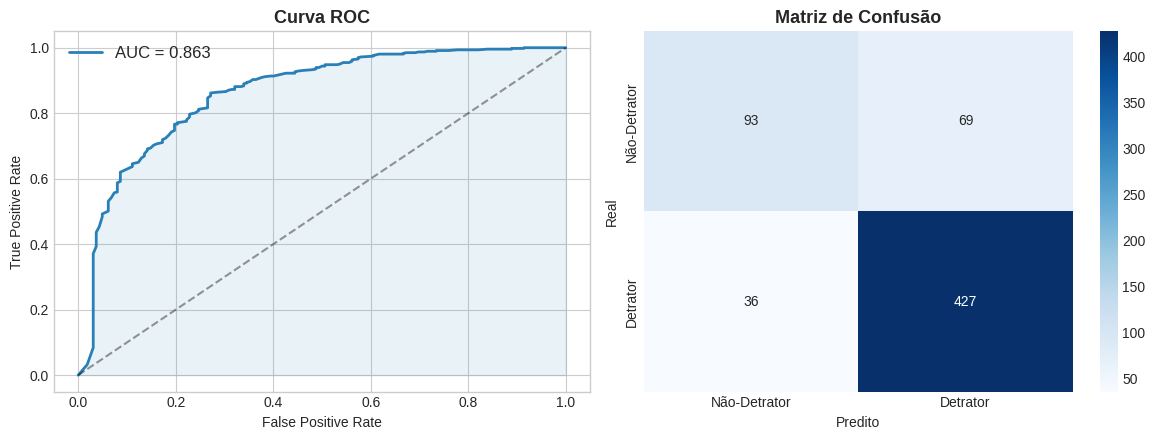


📊 AUC-ROC: 0.863

              precision    recall  f1-score   support

Não-Detrator       0.72      0.57      0.64       162
    Detrator       0.86      0.92      0.89       463

    accuracy                           0.83       625
   macro avg       0.79      0.75      0.76       625
weighted avg       0.82      0.83      0.83       625



In [6]:
# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Treinar Random Forest
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predições
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

# Visualização: ROC + Matriz de Confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#2980b9', linewidth=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Não-Detrator', 'Detrator'], yticklabels=['Não-Detrator', 'Detrator'])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusão', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('docs/03_modelo_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 AUC-ROC: {auc:.3f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Não-Detrator', 'Detrator'])}")

## 6. Importância das Features

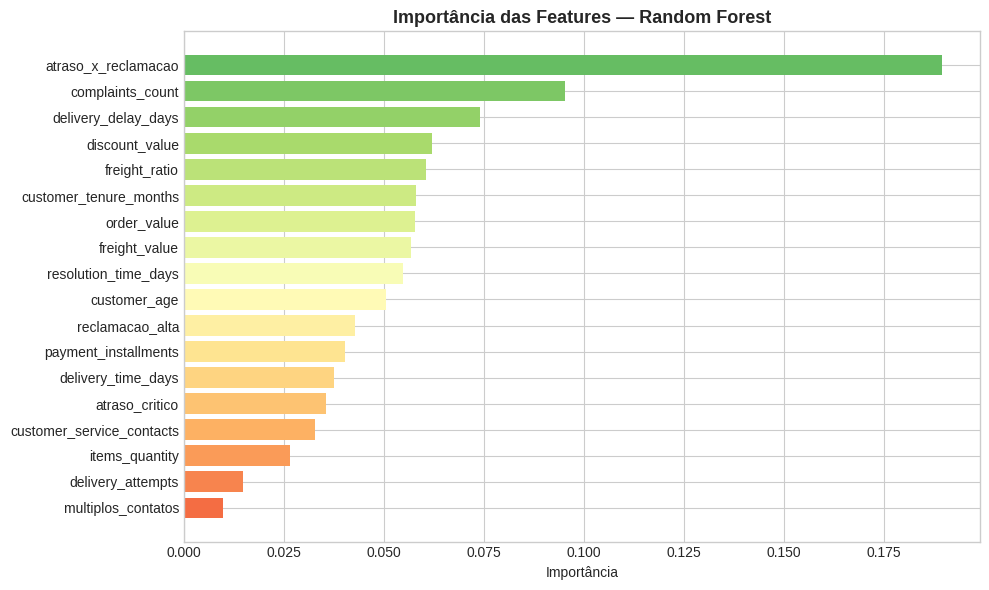

In [7]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(importances)))
ax.barh(importances.index, importances.values, color=colors_fi)
ax.set_title('Importância das Features — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')

plt.tight_layout()
plt.savefig('docs/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Score de Risco Operacional

Transformando a probabilidade do modelo em **faixas de risco acionáveis** pela operação.

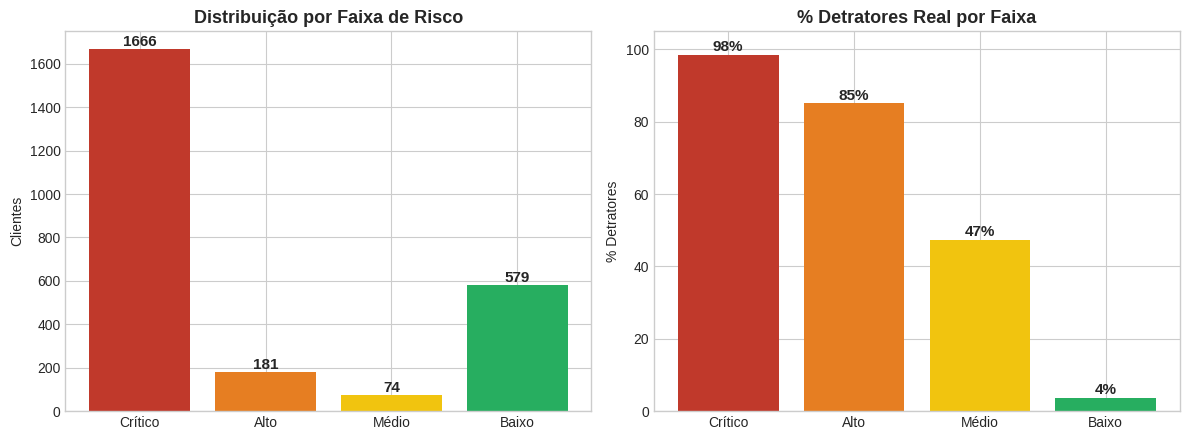


📋 Resumo por faixa de risco:
           clientes  detratores_reais taxa_detratores  nps_medio  atraso_medio
risk_band                                                                     
Crítico        1666              1641           98.5%        3.2           2.7
Alto            181               154           85.1%        4.8           1.3
Médio            74                35           47.3%        6.1           1.2
Baixo           579                21            3.6%        7.5           1.1


In [8]:
# Score de risco para todos os clientes
df['risk_score'] = model.predict_proba(X)[:, 1] * 100

def risk_band(score):
    if score >= 80: return 'Crítico'
    elif score >= 60: return 'Alto'
    elif score >= 40: return 'Médio'
    else: return 'Baixo'

df['risk_band'] = df['risk_score'].apply(risk_band)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Distribuição de risco
band_order = ['Crítico', 'Alto', 'Médio', 'Baixo']
band_colors = {'Crítico': '#c0392b', 'Alto': '#e67e22', 'Médio': '#f1c40f', 'Baixo': '#27ae60'}
band_counts = df['risk_band'].value_counts().reindex(band_order)
axes[0].bar(band_counts.index, band_counts.values, color=[band_colors[b] for b in band_counts.index])
for i, (cat, val) in enumerate(zip(band_counts.index, band_counts.values)):
    axes[0].text(i, val + 15, f'{val}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Distribuição por Faixa de Risco', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Clientes')

# Taxa de detratores real por faixa
real_rate = df.groupby('risk_band')['is_detractor'].mean().reindex(band_order) * 100
axes[1].bar(real_rate.index, real_rate.values, color=[band_colors[b] for b in real_rate.index])
for i, (cat, val) in enumerate(zip(real_rate.index, real_rate.values)):
    axes[1].text(i, val + 1, f'{val:.0f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('% Detratores Real por Faixa', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% Detratores')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('docs/05_score_risco.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela resumo
print("\n📋 Resumo por faixa de risco:")
summary = df.groupby('risk_band').agg(
    clientes=('customer_id', 'count'),
    detratores_reais=('is_detractor', 'sum'),
    taxa_detratores=('is_detractor', 'mean'),
    nps_medio=('nps_score', 'mean'),
    atraso_medio=('delivery_delay_days', 'mean')
).reindex(band_order)
summary['taxa_detratores'] = (summary['taxa_detratores'] * 100).round(1).astype(str) + '%'
summary['nps_medio'] = summary['nps_medio'].round(1)
summary['atraso_medio'] = summary['atraso_medio'].round(1)
print(summary.to_string())

## 8. Exemplo de Uso — Top 10 Clientes em Risco

Na operação real, essa lista seria gerada diariamente para ação preventiva do SAC.

In [9]:
# Top 10 clientes com maior risco
top_risk = df.nlargest(10, 'risk_score')[['customer_id', 'risk_score', 'risk_band', 'nps_score',
    'delivery_delay_days', 'complaints_count', 'customer_service_contacts']].reset_index(drop=True)

top_risk.columns = ['Cliente', 'Score Risco (%)', 'Faixa', 'NPS Real', 'Dias Atraso', 'Reclamações', 'Contatos SAC']
top_risk['Score Risco (%)'] = top_risk['Score Risco (%)'].round(1)
print("🚨 Top 10 clientes com maior probabilidade de detração:\n")
print(top_risk.to_string(index=False))

🚨 Top 10 clientes com maior probabilidade de detração:

 Cliente  Score Risco (%)   Faixa  NPS Real  Dias Atraso  Reclamações  Contatos SAC
       6            100.0 Crítico       0.9            5            5             2
      18            100.0 Crítico       4.8            3            4             1
      47            100.0 Crítico       2.3            6            5             1
      48            100.0 Crítico       3.4            3            6             3
      62            100.0 Crítico       0.0            4            5             1
      66            100.0 Crítico       3.9            3            8             3
      68            100.0 Crítico       2.7            4            7             4
      69            100.0 Crítico       0.0            4            9             5
      70            100.0 Crítico       0.0            2            8             3
      87            100.0 Crítico       2.9            3            5             2


---

## Conclusão

O modelo transforma o NPS de um **indicador retroativo** em uma **ferramenta de priorização preventiva**:

| Antes | Depois |
|-------|--------|
| Saber que o cliente é detrator **após** a pesquisa | Antecipar a detração **antes** da pesquisa |
| Atendimento reativo | SAC priorizado por score de risco |
| Ações genéricas para todos | Intervenções direcionadas por faixa |

**Próximos passos:** integrar o score ao fluxo de pedidos em tempo real, definir SLAs por faixa de risco e monitorar drift do modelo.

---
*Para detalhes completos da análise, consulte as pastas individuais do repositório.*